# EDA - PWC Multilabel Dataset
Analisi esplorativa del dataset multilabel estratto da Papers With Code (PWC).
Le label associate a ciascun record sono separate da `|`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [2]:
# 1. Caricamento Dati
import ast

df_ai = pd.read_csv('../data/processed/pwc_ai_filtered.csv')

def clean_and_extract_tasks(tasks_str):
    if pd.isna(tasks_str): return ''
    try: tasks = ast.literal_eval(tasks_str)
    except: return ''
    unique_tasks = set()
    for task in tasks:
        if isinstance(task, str):
            unique_tasks.add(task.strip().lower())
    return '|'.join(sorted(list(unique_tasks)))

df_multilabel = pd.DataFrame()
# Nel caso l'abstract sia nullo (NaN), lo colmiamo con il title e normalizziamo a minuscolo
df_multilabel['description'] = df_ai['abstract'].fillna(df_ai['title']).str.lower()

# Se anche il titolo risulta NaN (la riga rimane NaN), allora effettuiamo il drop
df_multilabel.dropna(subset=['description'], inplace=True)

# Recupera le label ripulite per questo subset
df_multilabel['labels'] = df_ai.loc[df_multilabel.index, 'tasks'].apply(clean_and_extract_tasks)
df_multilabel = df_multilabel[df_multilabel['labels'] != ''].copy()
df_multilabel.reset_index(drop=True, inplace=True)

print(f"Dimensioni dataset: {df_multilabel.shape}")
display(df_multilabel.head())

Dimensioni dataset: (326546, 2)


,description,labels
0,can evolving networks be inferred and modeled ...,modelopen-ended question answering
1,this paper investigates the automated recognit...,big-bench machine learning
2,in order to provide the right type of assistan...,self-supervised learningsurgical phase recogni...
3,many estimators of the average effect of a tre...,regression
4,a unified approach to explain the output of an...,big-bench machine learning


In [3]:
# 2. Parsing delle Label
# Creiamo una lista di label per ogni record dividendo per '|'
df_multilabel['labels_list'] = df_multilabel['labels'].fillna('').apply(lambda x: [l for l in str(x).split('|') if l.strip()])

# Calcolo del numero di label per record (Cardinality)
df_multilabel['label_count'] = df_multilabel['labels_list'].apply(len)

print("Statistiche Cardinalità delle label:")
display(df_multilabel['label_count'].describe())

Statistiche Cardinalità delle label:


count    326546.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: label_count, dtype: float64

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_52547/3714631290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_multilabel, x='label_count', palette='viridis')


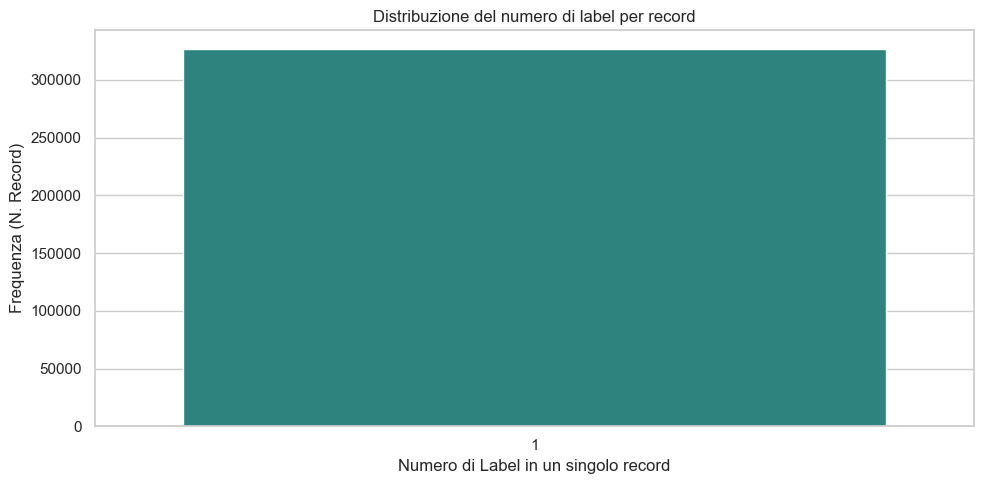

In [4]:
# 3. Distribuzione del Numero di Label per Record
plt.figure(figsize=(10, 5))
sns.countplot(data=df_multilabel, x='label_count', palette='viridis')
plt.title('Distribuzione del numero di label per record')
plt.xlabel('Numero di Label in un singolo record')
plt.ylabel('Frequenza (N. Record)')
plt.tight_layout()
plt.show()

Numero totale di singole label (uniche): 143044


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_52547/1956865578.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_label_freq.head(60), x='count', y='label', palette='mako')


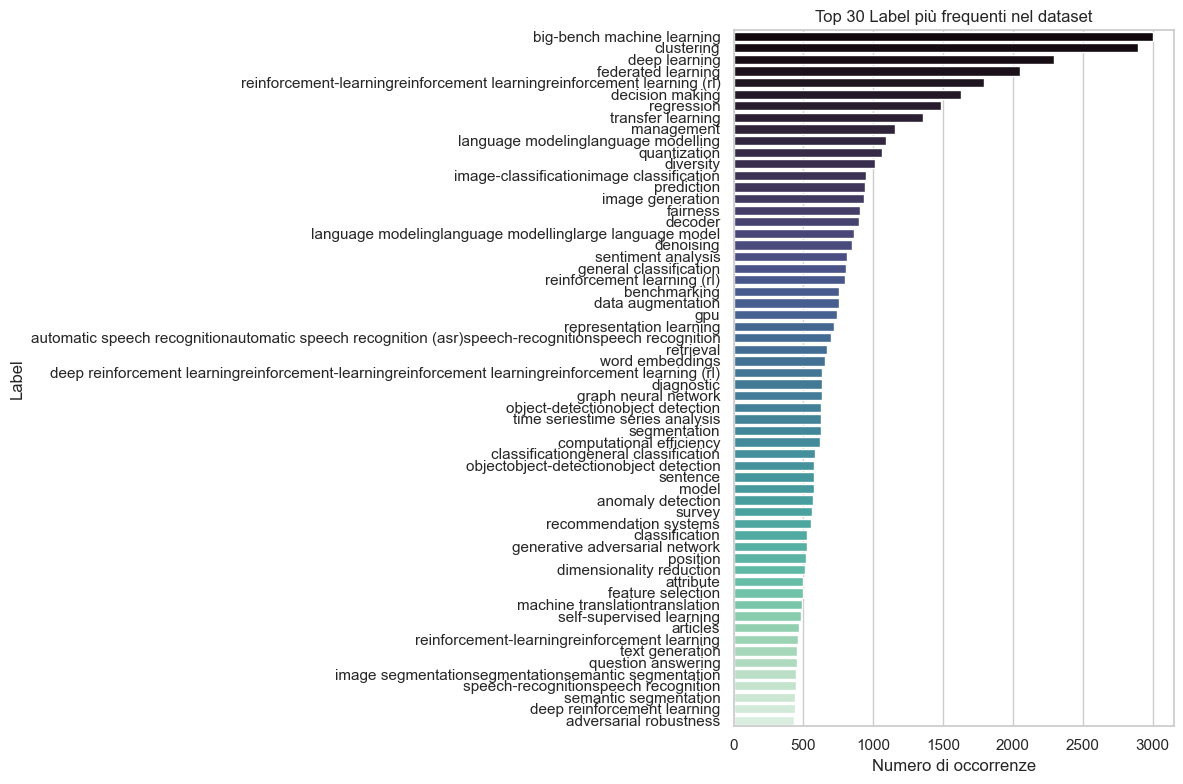

In [5]:
# 4. Frequenza delle Singole Label
all_labels = [label for labels in df_multilabel['labels_list'] for label in labels]
label_counts = Counter(all_labels)

print(f"Numero totale di singole label (uniche): {len(label_counts)}")

# Convertiamo in DataFrame per il plot
df_label_freq = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count']).reset_index()
df_label_freq = df_label_freq.rename(columns={'index': 'label'}).sort_values('count', ascending=False)

plt.figure(figsize=(12, 8))
# Mostriamo le top 30 label
sns.barplot(data=df_label_freq.head(60), x='count', y='label', palette='mako')
plt.title('Top 30 Label più frequenti nel dataset')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_52547/368078864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_multilabel[df_multilabel['label_count'] <= 50], x='label_count', y='desc_length', palette='Set2')


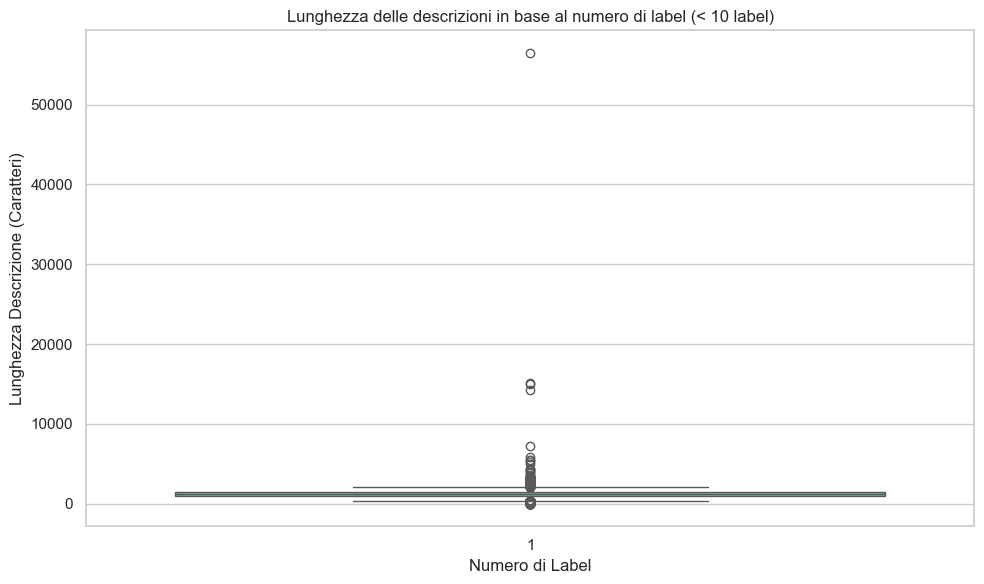

In [6]:
# 5. Lunghezza delle descrizioni basata sul numero di label
df_multilabel['desc_length'] = df_multilabel['description'].fillna('').astype(str).str.len()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_multilabel[df_multilabel['label_count'] <= 50], x='label_count', y='desc_length', palette='Set2')
plt.title('Lunghezza delle descrizioni in base al numero di label (< 10 label)')
plt.xlabel('Numero di Label')
plt.ylabel('Lunghezza Descrizione (Caratteri)')
plt.tight_layout()
plt.show()

In [7]:
# 6. Top 20 record con il maggior numero di label
print("Top 20 record con il maggior numero di label:")
display(df_multilabel.sort_values('label_count', ascending=False)[['description', 'labels', 'label_count']].head(20))

Top 20 record con il maggior numero di label:


,description,labels,label_count
0,can evolving networks be inferred and modeled ...,modelopen-ended question answering,1
217694,current fairness toolkits in machine learning ...,fairness,1
217701,graph neural network (gnn) research has produc...,graph neural network,1
217700,training and inference in gaussian processes (...,gaussian processeshyperparameter optimization,1
217699,large language models (llms) with hundreds of ...,in-context learning,1
217698,we present a novel extension to the family of ...,atari gamesreinforcement-learning,1
217697,recent progress in natural language processing...,music generationmusic information retrieval,1
217696,understanding neural networks is challenging i...,quantization,1
217695,in some settings neural networks exhibit a phe...,regression,1
217693,software quality assurance activities become i...,prediction,1


# 7. Labels Mapping e Normalizzazione
Definiamo un dizionario per mappare le centinaia di label in circa 20-30 macro categorie e applichiamolo al dataset.

In [8]:
macro_mapping = {
    'Advanced Training': [
        'reinforcement learning', 'reinforcement learning (rl)', 'deep reinforcement learning', 
        'q learning', 'multi agent reinforcement learning', 'imitation learning', 
        'continuous control', 'sequential decision making', 'offline reinforcement learning',
        'representation learning', 'contrastive learning', 'self supervised learning', 'graph learning',
        'generative adversarial training', 'generative adversarial training (gat)', 'gat'
    ],
    'Natural Language Processing': [
        'language modelling', 'language modeling', 'sentence', 
        'natural language understanding', 'natural language inference', 'semantic textual similarity',
        'word embeddings', 'text classification', 'sentiment analysis', 'sentiment classification', 
        'named entity recognition', 'named entity recognition (ner)', 'ner', 'relation extraction', 
        'text summarization', 'wordcloud', 'topic modeling', 'coreference resolution'
    ],
    'Computer Vision': [
        'object detection', 'image classification', 'image segmentation', 'pose estimation',
        'instance segmentation', 'visual question answering', 'visual question answering (vqa)', 
        'object recognition', 'face recognition', '3d object detection', 'optical flow estimation',
        'scene understanding', 'image captioning', 'depth estimation', '3d reconstruction',
        'person re identification', 'object tracking', 'action recognition', 'activity recognition',
        'medical image segmentation', 'medical image analysis', 'visual servoing',
    ],
    'Classification & Regression': [
        'classification', 'general classification', 'binary classification', 
        'multi label classification', 'regression', 'node classification', 'graph classification'
    ],
    'Clustering & Segmentation': [
        'clustering', 'semantic segmentation', 'segmentation', 'video semantic segmentation'
    ],
    'Transfer Learning & Fine-Tuning': [
        'transfer learning', 'domain adaptation', 'domain generalization', 
        'unsupervised domain adaptation', 'knowledge distillation', 'model fine tuning', 
        'fine tuning'
    ],
    'Deep Learning Architectures': [
        'deep learning', 'decoder', 'graph neural network', 'generative adversarial network', 
         'neural architecture search',
        'nerf', 'graph embedding'
    ],
    'Information Retrieval & QA': [
        'retrieval', 'question answering', 'information retrieval', 'retrieval augmented generation', 
        'rag', 'reading comprehension', 'image retrieval'
    ],
    'Translation': [
        'translation', 'machine translation', 'nmt',
        'llm translation', 'language translation'
    ],
    'Time Series & Forecasting': [
        'time series', 'time series analysis', 'time series forecasting', 'prediction', 'time series transformer',
        'temporal graph networks', 'temporal graph learning'
    ],
    'Small Language Models & Distillation': [
        'small language model', 'small language models', 'distillation', 'model compression',
        'quantization', 'parameter efficient fine tuning', 'slm', 'small language model (slm)', 
        'small language models (slm)', 'vision small language model', 'vision small language models', 
        'vslm', 'vision small language model (vslm)'
    ],
    'GenAI': [
        'data augmentation', 'image generation', 'text generation', 'code generation', 
        'video generation', 'video summarization', 'speech synthesis', 'text to image generation', 'style transfer', 
        'text to video generation', 'text to speech', 'prompt engineering', 'text to image', 
        'text to video', 'text to speech synthesis', 'large language model', 'llm', 'large language models', 'llms',
        'mixture of experts', 'mamba', 'mixture of experts (mamba)', 'multimodal generation', 'multimodal generation (mamba)', 
        'multimodal large language model', 'denoising', 'diffusion', 'diffusion models', 'diffusion model'
    ],
    'Agentic Systems & Multi-Agent': [
        'agentic systems', 'multi agent systems', 'multi agent reinforcement learning', 'autonomous agents', 
        'agent based modeling', 'agent based simulation', 'ai agent', 'agent swarm', 'mcp', 'model context procotol'
    ],
    'Speech & Audio': [
        'speech recognition', 'automatic speech recognition', 'automatic speech recognition (asr)', 
        'vocal bursts intensity prediction', 'emotion recognition'
    ],
    'Optimization & Efficiency': [
        'quantization', 'model compression', 'computational efficiency', 'parameter efficient fine tuning',
        'gpu', 'cpu', 'scheduling', 'bayesian optimization', 'combinatorial optimization', 'stochastic optimization',
        'hyperparameter optimization', 'hyperparameter tuning', 'model pruning', 'sparse training', 'efficient training', 
        'efficient inference'
    ],
    'Anomaly Detection & Security': [
        'anomaly detection', 'adversarial attack', 'adversarial robustness', 'privacy preserving',
        'misinformation'
    ],
    'Ethics, Fairness & Explainability': [
        'fairness', 'explainable artificial intelligence', 'explainable artificial intelligence (xai)',
        'diversity', 'bias', 'diagnostic'
    ],
    'Decision Making & Reasoning': [
        'decision making', 'math', 'knowledge graphs', 'causal inference'
    ],
    'Few-Shot & Meta Learning': [
        'few shot learning', 'meta learning', 'zero shot learning', 'active learning', 
        'continual learning', 'incremental learning', 'multi task learning'
    ],
    'Autonomous Systems': [
        'autonomous driving', 'autonomous vehicles', 'robotics', 'robotic manipulation', 'robotic grasping', 'robotic control',
        'visual servoing', 'simultaneous localization and mapping', 'slam', 'robotic navigation', 'llm controlled drone', 'agentic unmanned vehicle',
        'vision language action model', 'vla', 'vision language action model (vla)', 'autonomous systems', 'vision language action'
    ]
}

# Funzione per invertire il dizionario {sottocategoria: MacroCategoria}
reverse_mapping = {}
for macro, sub_labels in macro_mapping.items():
    for sub in sub_labels:
        reverse_mapping[sub.lower()] = macro

def map_labels(label_list):
    mapped = set()
    for lbl in label_list:
        lbl_lower = lbl.lower()
        if lbl_lower in reverse_mapping:
            mapped.add(reverse_mapping[lbl_lower])
        else:
            # Se la label non è tra le top specificate, la mettiamo in "Other AI/ML Techniques"
            mapped.add('Other AI/ML Techniques')
    return list(mapped)

df_multilabel['mapped_labels'] = df_multilabel['labels_list'].apply(map_labels)
df_multilabel['mapped_label_count'] = df_multilabel['mapped_labels'].apply(len)

print("Esempio di mapping:")
display(df_multilabel[['labels_list', 'mapped_labels']].head(10))

Esempio di mapping:


,labels_list,mapped_labels
0,[modelopen-ended question answering],[Other AI/ML Techniques]
1,[big-bench machine learning],[Other AI/ML Techniques]
2,[self-supervised learningsurgical phase recogn...,[Other AI/ML Techniques]
3,[regression],[Classification & Regression]
4,[big-bench machine learning],[Other AI/ML Techniques]
5,[dimensionality reductionretrieval],[Other AI/ML Techniques]
6,[anatomyimage segmentationsegmentationsemantic...,[Other AI/ML Techniques]
7,[mixture-of-expertsrelational reasoningvisual ...,[Other AI/ML Techniques]
8,[video summarization],[GenAI]
9,[3d geometry],[Other AI/ML Techniques]


Numero totale di macro-categorie (uniche): 21


/var/folders/5_/mnr70g2511s9w_v5w224k2x00000gn/T/ipykernel_52547/458756513.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_mapped_freq, x='count', y='macro_label', palette='mako')


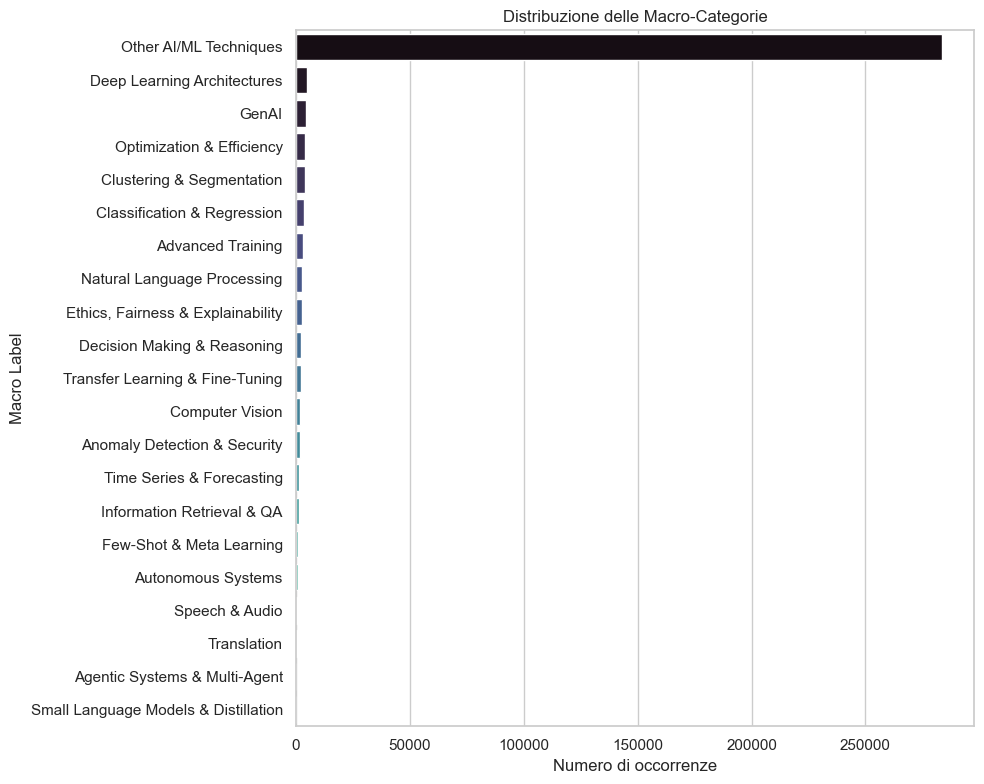

In [9]:
# 8. Analisi delle nuove Label Mappate
all_mapped_labels = [label for labels in df_multilabel['mapped_labels'] for label in labels]
mapped_label_counts = Counter(all_mapped_labels)

print(f"Numero totale di macro-categorie (uniche): {len(mapped_label_counts)}")

# Convertiamo in DataFrame per il plot
df_mapped_freq = pd.DataFrame.from_dict(mapped_label_counts, orient='index', columns=['count']).reset_index()
df_mapped_freq = df_mapped_freq.rename(columns={'index': 'macro_label'}).sort_values('count', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=df_mapped_freq, x='count', y='macro_label', palette='mako')
plt.title('Distribuzione delle Macro-Categorie')
plt.xlabel('Numero di occorrenze')
plt.ylabel('Macro Label')
plt.tight_layout()
plt.show()

In [10]:
# 8.1 Top 20 record con il maggior numero di macro-label (dopo il mapping)
print("Top 20 record con il maggior numero di macro-label (dopo la normalizzazione):")
display(df_multilabel.sort_values('mapped_label_count', ascending=False)[['description', 'mapped_labels', 'mapped_label_count']].head(20))

Top 20 record con il maggior numero di macro-label (dopo la normalizzazione):


,description,mapped_labels,mapped_label_count
0,can evolving networks be inferred and modeled ...,[Other AI/ML Techniques],1
217694,current fairness toolkits in machine learning ...,"[Ethics, Fairness & Explainability]",1
217701,graph neural network (gnn) research has produc...,[Deep Learning Architectures],1
217700,training and inference in gaussian processes (...,[Other AI/ML Techniques],1
217699,large language models (llms) with hundreds of ...,[Other AI/ML Techniques],1
217698,we present a novel extension to the family of ...,[Other AI/ML Techniques],1
217697,recent progress in natural language processing...,[Other AI/ML Techniques],1
217696,understanding neural networks is challenging i...,[Optimization & Efficiency],1
217695,in some settings neural networks exhibit a phe...,[Classification & Regression],1
217693,software quality assurance activities become i...,[Time Series & Forecasting],1


In [11]:
# 9. Salvataggio del nuovo Dataset Normalizzato
# Riassembliamo le liste mappate in una stringa separata da '|'
df_multilabel['final_labels'] = df_multilabel['mapped_labels'].apply(lambda x: '|'.join(x))

df_mapped_export = df_multilabel.drop(columns=['labels_list', 'label_count', 'desc_length', 'mapped_labels', 'mapped_label_count'])

output_path = '../data/processed/pwc_ai_multilabel_mapped.csv'
df_mapped_export.to_csv(output_path, index=False)
print(f"Nuovo dataset salvato correttamente in: {output_path}")

print(f"\nPrime righe del nuovo dataset salvato:\n")
display(df_mapped_export.head())

Nuovo dataset salvato correttamente in: ../data/processed/pwc_ai_multilabel_mapped.csv

Prime righe del nuovo dataset salvato:



,description,labels,final_labels
0,can evolving networks be inferred and modeled ...,modelopen-ended question answering,Other AI/ML Techniques
1,this paper investigates the automated recognit...,big-bench machine learning,Other AI/ML Techniques
2,in order to provide the right type of assistan...,self-supervised learningsurgical phase recogni...,Other AI/ML Techniques
3,many estimators of the average effect of a tre...,regression,Classification & Regression
4,a unified approach to explain the output of an...,big-bench machine learning,Other AI/ML Techniques
